In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
plt.style.use('fivethirtyeight')
from datetime import datetime
from sklearn.ensemble import IsolationForest
from statsmodels.graphics import tsaplots
import statsmodels.api as sm
from pylab import rcParams
import warnings 
warnings.filterwarnings("ignore")
import pickle

In [2]:
top_page_df = pd.read_csv('final_data.csv')
top_page_df = top_page_df.set_index('Date')

In [3]:
train = top_page_df[:'2016-09']
test = top_page_df['2016-10':]

In [4]:
train_log = np.log1p(train)
test_log = np.log1p(test)

In [5]:
train_diff = train_log.diff().dropna()
test_diff = test_log.diff().dropna()

In [6]:
scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_diff), columns=train.columns, index=train_diff.index)
test_scaled = pd.DataFrame(scaler.transform(test_diff), columns=test.columns, index=test_diff.index)

In [7]:
def transform_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 7

In [8]:
X_train, y_train = transform_dataset(train_scaled, train_scaled.Views, time_steps)
X_test, y_test = transform_dataset(test_scaled, test_scaled.Views, time_steps)

### Code to evaluate rmse for each model

In [9]:
def evaluate_lstm_model(model, model_name, X_train, y_train, X_test, y_test, test_index, plot_history=True):
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=16,
        validation_split=0.1,
        verbose=1,
        shuffle=False
    )

    if plot_history:
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
        plt.title(f'{model_name} - Loss Curve')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')
        plt.show()

    y_pred = model.predict(X_test)

    y_pred_inv = scaler.inverse_transform(
        np.concatenate([y_pred, np.zeros((y_pred.shape[0], train.shape[1] - 1))], axis=1))[:, 0]
    y_test_inv = scaler.inverse_transform(
        np.concatenate([y_test.reshape(-1, 1), np.zeros((y_test.shape[0], train.shape[1] - 1))], axis=1))[:, 0]

    last_values = test_log.Views.shift(time_steps).dropna().values[:len(y_pred_inv)]
    y_pred_inv += last_values
    y_test_inv += last_values
    test_index = test.index[-len(y_pred_inv):]

    y_pred_final = np.expm1(y_pred_inv)
    y_test_final = np.expm1(y_test_inv)

    fig, ax = plt.subplots()
    pd.DataFrame({'Date': test_index, 'Views': y_test_final}).plot('Date', ax=ax)
    pd.DataFrame({'Date': test_index, 'Views': y_pred_final}).plot('Date', ax=ax)
    plt.legend(['Actual', 'Forecast'], loc='upper left')
    plt.title(f'{model_name} - Forecast vs Actual')
    plt.ylabel('Views (in million)')
    plt.show()

    rmse = np.sqrt(np.mean(np.square(y_pred_final - y_test_final)))
    print(f'{model_name} - RMSE: {rmse:.4f}')

    return rmse


## LSTM

In [10]:
model = keras.Sequential()
model.add(keras.layers.LSTM(
  units=128,
  input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(keras.layers.Dense(units=1))
model.compile(
  loss='mean_squared_error',
  optimizer=keras.optimizers.RMSprop()
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.1003 - val_loss: 0.0085
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0107 - val_loss: 0.0102
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0114 - val_loss: 0.0129
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0112 - val_loss: 0.0080
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0109 - val_loss: 0.0151
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0115 - val_loss: 0.0076
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0107 - val_loss: 0.0140
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0112 - val_loss: 0.0074
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0105 - val_loss: 0.0137
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0110 - val_loss: 0.0070
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0103 - val_loss: 0.0130
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

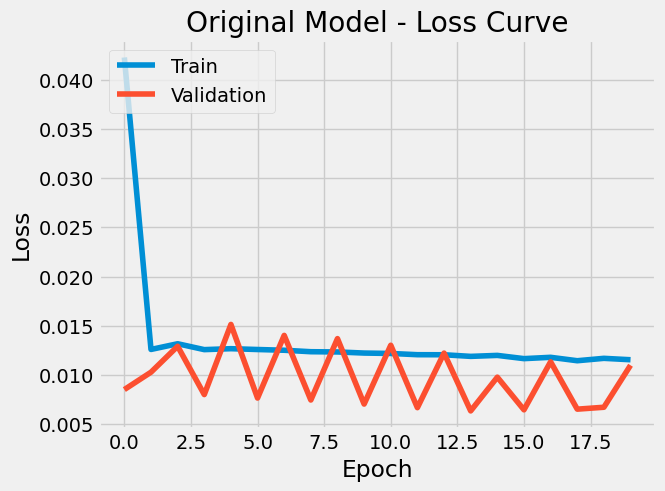

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


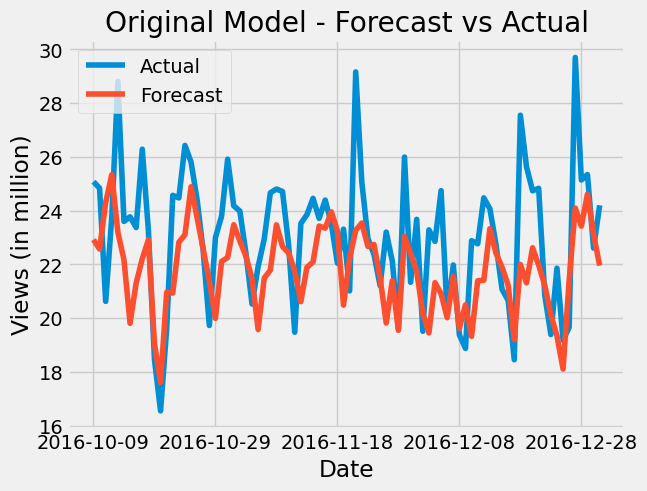

Original Model - RMSE: 2.3237


In [11]:
rmse1 = evaluate_lstm_model(model, 'Original Model', X_train, y_train, X_test, y_test, test.index)

In [12]:
model2 = keras.Sequential()
model2.add(keras.layers.LSTM(
  units=256,
  input_shape=(X_train.shape[1], X_train.shape[2]),
  return_sequences=False,
  dropout=0.2,
  recurrent_dropout=0.2
))
model2.add(keras.layers.Dense(units=1))
model2.compile(
  loss='mean_squared_error',
  optimizer=keras.optimizers.Adam(learning_rate=0.001)
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1268 - val_loss: 0.0148
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0374 - val_loss: 0.0070
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0175 - val_loss: 0.0065
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0105 - val_loss: 0.0064
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0097 - val_loss: 0.0066
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0108 - val_loss: 0.0064
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0101 - val_loss: 0.0063
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0098 - val_loss: 0.0063
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0098 - val_loss: 0.0063
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0097 - val_loss: 0.0062
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0097 - val_loss: 0.0062
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

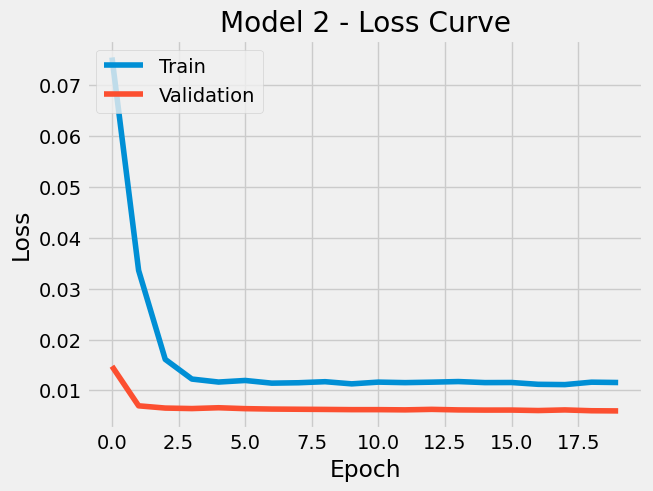

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step


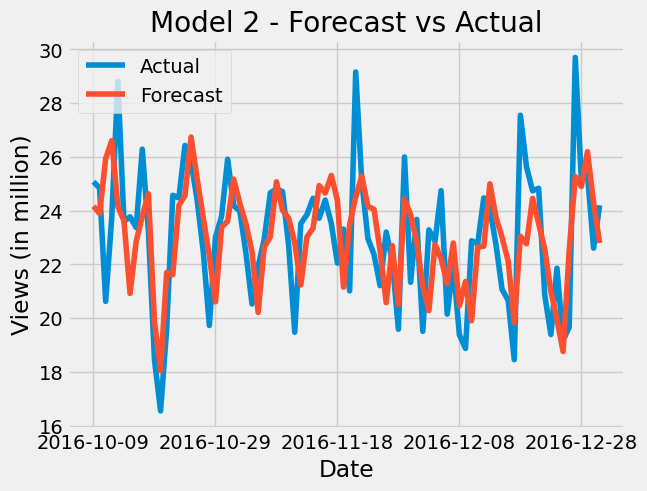

Model 2 - RMSE: 2.0061


In [13]:
rmse2 = evaluate_lstm_model(model2, 'Model 2', X_train, y_train, X_test, y_test, test.index)

In [14]:
model3 = keras.Sequential()
model3.add(keras.layers.LSTM(
  units=64,
  return_sequences=True,
  input_shape=(X_train.shape[1], X_train.shape[2])
))
model3.add(keras.layers.LSTM(units=32))
model3.add(keras.layers.Dense(units=1))
model3.compile(
  loss='mean_squared_error',
  optimizer=keras.optimizers.Adam(learning_rate=0.0005)
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.2032 - val_loss: 0.0066
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0142 - val_loss: 0.0078
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0111 - val_loss: 0.0063
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0102 - val_loss: 0.0062
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0101 - val_loss: 0.0062
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0101 - val_loss: 0.0062
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0101 - val_loss: 0.0062
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0101 - val_loss: 0.0062
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0101 - val_loss: 0.0062
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0100 - val_loss: 0.0062
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0100 - val_loss: 0.0062
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

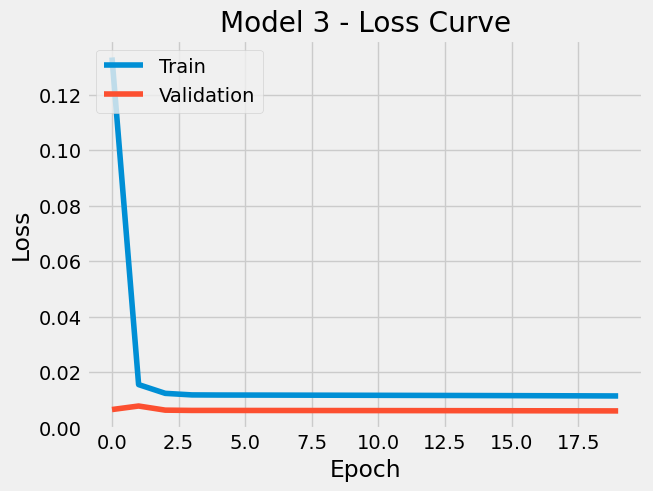

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001D1873077E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step


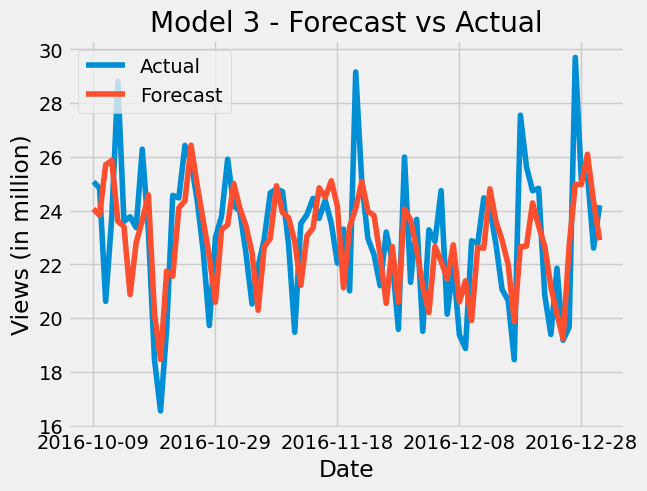

Model 3 - RMSE: 2.0473


In [15]:
rmse3 = evaluate_lstm_model(model3, 'Model 3', X_train, y_train, X_test, y_test, test.index)

In [16]:
model4 = keras.Sequential()
model4.add(keras.layers.Bidirectional(
  keras.layers.LSTM(units=64),
  input_shape=(X_train.shape[1], X_train.shape[2])
))
model4.add(keras.layers.Dense(units=1))
model4.compile(
  loss='mean_squared_error',
  optimizer=keras.optimizers.Adam(learning_rate=0.001)
)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.1440 - val_loss: 0.0084
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0121 - val_loss: 0.0068
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0109 - val_loss: 0.0067
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0106 - val_loss: 0.0066
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0105 - val_loss: 0.0065
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0105 - val_loss: 0.0065
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0104 - val_loss: 0.0065
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0104 - val_loss: 0.0064
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0103 - val_loss: 0.0064
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0103 - val_loss: 0.0064
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0102 - val_loss: 0.0063
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0101 -

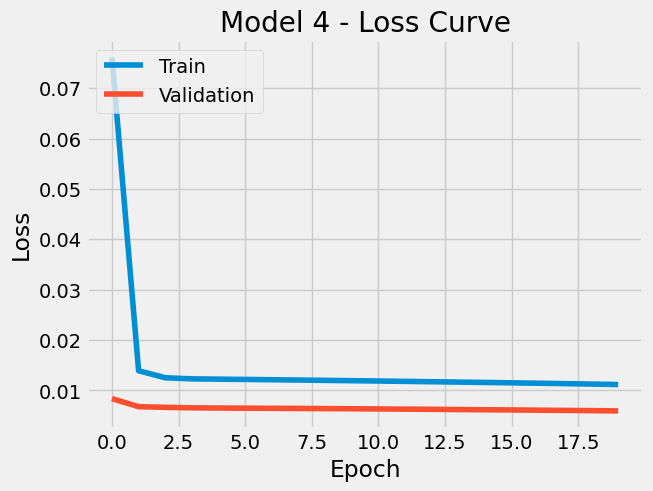

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step


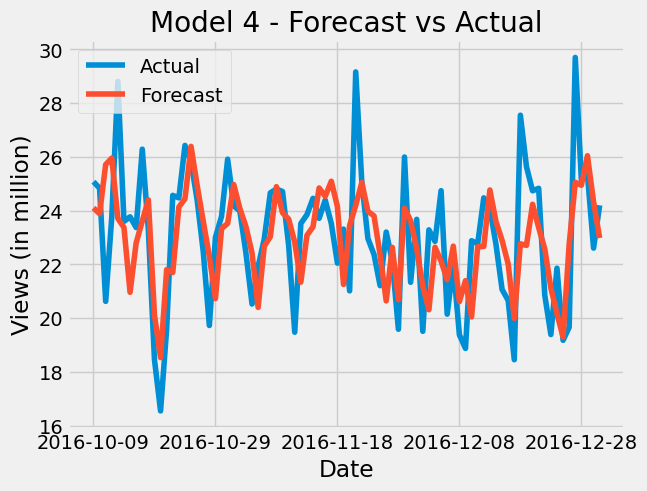

Model 4 - RMSE: 2.0153


In [17]:
rmse4 = evaluate_lstm_model(model4, 'Model 4', X_train, y_train, X_test, y_test, test.index)

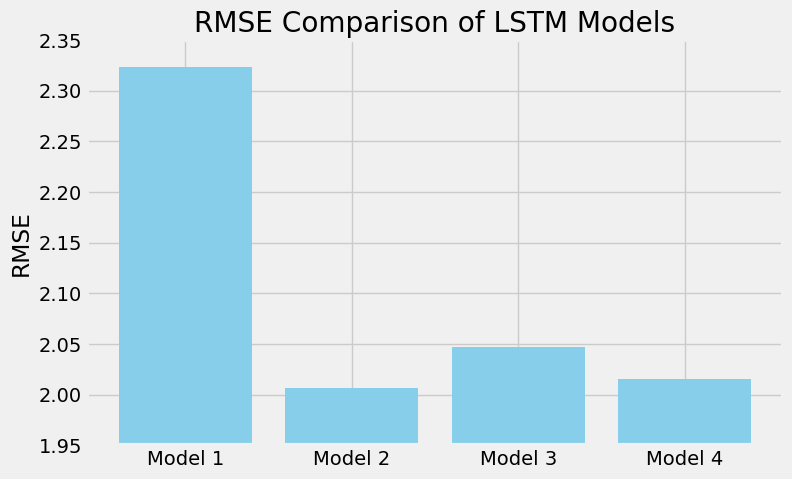

In [21]:
models = ['Model 1', 'Model 2', 'Model 3', 'Model 4']
rmses = [rmse1, rmse2, rmse3, rmse4]

plt.figure(figsize=(8,5))
plt.bar(models, rmses, color='skyblue')
plt.ylabel('RMSE')
plt.title('RMSE Comparison of LSTM Models')
plt.ylim(1.95, 2.35)
plt.show()